## 2. Описание датасета

**Название:** OpenSky States Snapshot Dataset
**Источник:** https://www.kaggle.com/datasets/ibrahimqasimi/opensky
**Предметная область:** авиация, мониторинг воздушного движения
**Характер данных:** реальные наблюдения (ADS-B сигналы от самолетов)

**Описание:**
Датасет представляет собой снимок состояния воздушного пространства, собранный сетью OpenSky.
Каждая строка соответствует одному самолету, для которого зафиксированы координаты, высота, скорость, направление, страна регистрации и другие параметры.

**Тип задачи:** анализ движения воздушного транспорта, определение плотности трафика, классификация или визуализация маршрутов.

## Атрибуты датасета

| Название атрибута | Тип данных         | Описание                                                                                      |
|--------------------|--------------------|-----------------------------------------------------------------------------------------------|
| `icao24` | строковый          | Уникальный 24-битный идентификатор самолёта (hex-код ICAO)                                    |
| `callsign` | строковый          | Позывной рейса, передаваемый самолётом (может быть пустым)                                    |
| `origin_country` | строковый          | Страна, в которой зарегистрирован самолёт                                                     |
| `time_position` | числовой (float64) | Время последнего позиционного сообщения (в милисекундах UNIX)                                 |
| `last_contact` | числовой (int64)   | Время последнего контакта с приёмником (в милисекундах UNIX)                                  |
| `longitude` | числовой (float64) | Географическая долгота текущего положения самолёта                                            |
| `latitude` | числовой (float64) | Географическая широта текущего положения самолёта                                             |
| `baro_altitude` | числовой (float64) | Барометрическая высота полёта (в метрах)                                                      |
| `on_ground` | логический (bool)  | Находится ли самолёт на земле (`True`/`False`)                                                |
| `velocity` | числовой (float64) | Горизонтальная скорость полёта (в м/с)                                                        |
| `true_track` | числовой (float64) | Азимутальное направление движения (в градусах, 0–360)                                         |
| `vertical_rate` | числовой (float64) | Вертикальная скорость (набор или снижение, в м/с)                                             |
| `sensors` | числовой (float64) | Идентификаторы сенсоров (в этом наборе отсутствуют данные)                                    |
| `geo_altitude` | числовой (float)64 | Геометрическая (GPS) высота над уровнем моря (в метрах)                                       |
| `squawk` | строковый          | Код транспондера (восьмиричный код, используется диспетчерами)                                |
| `spi` | логический (bool)  | Индикатор приоритета сообщения (Special Purpose Indicator)                                    |
| `position_source` | числовой (int64)   | Источник позиционных данных: 0 = ADS-B, 1 = ASTERIX, 2 = MLAT                                 |
| `latency` | числовой(float64) | Новый созданный столбец задержки между отправленым сообщением и его достижения приемником(мс) |


In [39]:
!pip install pandas
!pip install numpy matplotlib scikit-learn



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.cluster import KMeans

In [41]:
df = pd.read_csv("opensky_states_snapshot.csv")


In [42]:
df = df.dropna(subset=['time_position', 'last_contact'])
df['latency'] = df['last_contact'] - df['time_position']

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7359 entries, 0 to 7419
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   icao24           7359 non-null   object 
 1   callsign         7256 non-null   object 
 2   origin_country   7359 non-null   object 
 3   time_position    7359 non-null   float64
 4   last_contact     7359 non-null   int64  
 5   longitude        7359 non-null   float64
 6   latitude         7359 non-null   float64
 7   baro_altitude    6805 non-null   float64
 8   on_ground        7359 non-null   bool   
 9   velocity         7357 non-null   float64
 10  true_track       7359 non-null   float64
 11  vertical_rate    6794 non-null   float64
 12  sensors          0 non-null      float64
 13  geo_altitude     6712 non-null   float64
 14  squawk           4542 non-null   float64
 15  spi              7359 non-null   bool   
 16  position_source  7359 non-null   int64  
 17  latency          73

In [43]:
numeric_columns = ['time_position', 'last_contact', 'longitude', 'latitude', 'baro_altitude', 'velocity', 'true_track', 'vertical_rate', 'geo_altitude', 'latency']

df = df.drop_duplicates(subset=['icao24']) # удаление дублей

for col in numeric_columns:

    df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=[col])

    p_min = np.percentile(df[col], 2)
    p_max = np.percentile(df[col], 99)

    df = df [(df[col] <= p_max) & (df[col] >= p_min)]

df = df[(df['time_position'] >= 0)]
df = df[(df['last_contact'] >= 0)]
df = df[(df['longitude'] >= -180) & (df['longitude'] <= 180)] # долгота
df = df[(df['latitude'] >= -90) & (df['latitude'] <= 90)] # широта
df = df[(df['baro_altitude'] >= -100) & (df['baro_altitude'] <= 20000)]
df = df[(df['velocity'] >= 0) & (df['velocity'] <= 350)]
df = df[(df['true_track'] >= 0) & (df['true_track'] < 360)]
df = df[(df['geo_altitude'] >= -100) & (df['geo_altitude'] <= 20000)]
df = df[df['latency'] >= 0]


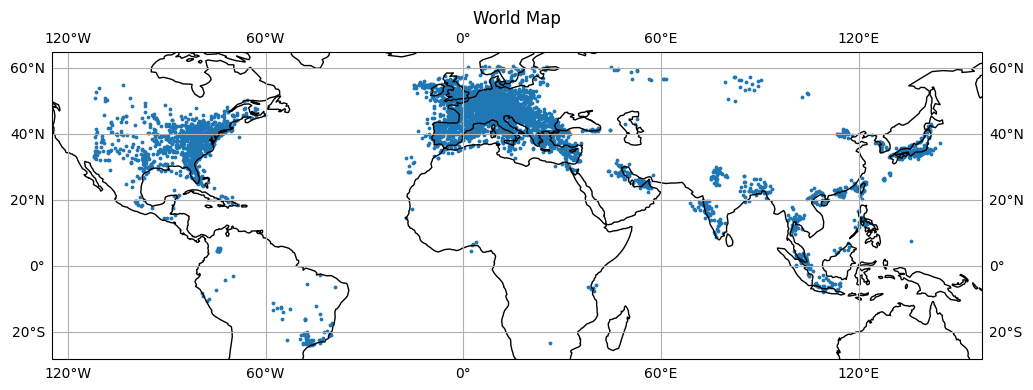

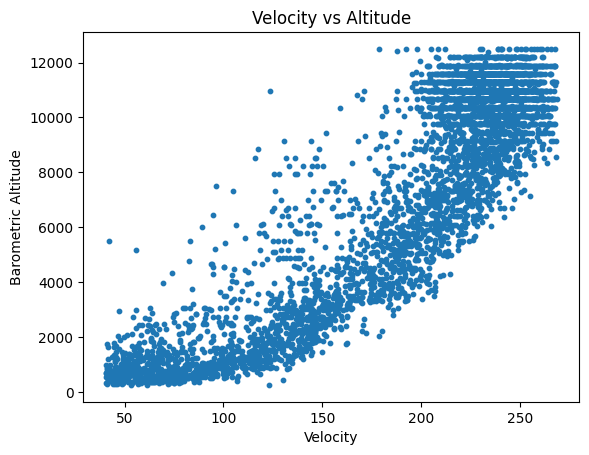

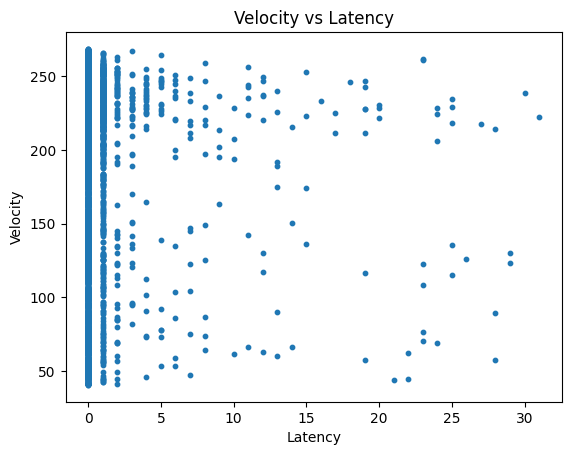

In [47]:
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines()         # нарисовать линии континентов
ax.gridlines(draw_labels=True)  # сетка широта/долгота

plt.scatter(
    df['longitude'],
    df['latitude'],
    s=3,
    transform=ccrs.PlateCarree()  # говорим, что lon/lat даны в географической системе
)
plt.title("World Map")
plt.show()


plt.scatter(df['velocity'], df['baro_altitude'], s=10)
plt.xlabel("Velocity")
plt.ylabel("Barometric Altitude")
plt.title("Velocity vs Altitude")
plt.show()


plt.scatter(df['latency'], df['velocity'], s=10)
plt.xlabel("Latency")
plt.ylabel("Velocity")
plt.title("Velocity vs Latency")
plt.show()


## World map (longitude vs latitude)

**Ярковыраженные кластеры:**
1. Территория США
2. Территория Европы



## velocity vs baro_altitude

**Ярковыраженные кластеры:**
1. Взлет/посадка(высота до 1000 м, скорость до 50 км/ч)
2. Набор высоты (средние скорости и высоты)
3. Крейсерский полёт (высокая скорость и высота)



## velocity vs latency

**Ярковыраженные кластеры:**
1. Большой плотный кластер latency ≈ 0…1 — это нормальная телеметрия.
2. Более редкие точки с latency 10+ — это самолёты, у которых сигнал задержался.

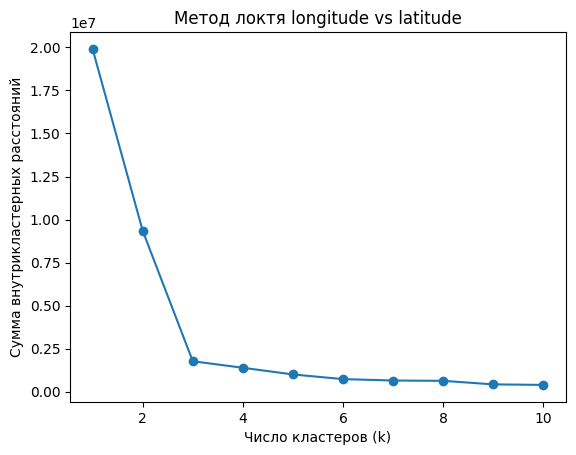

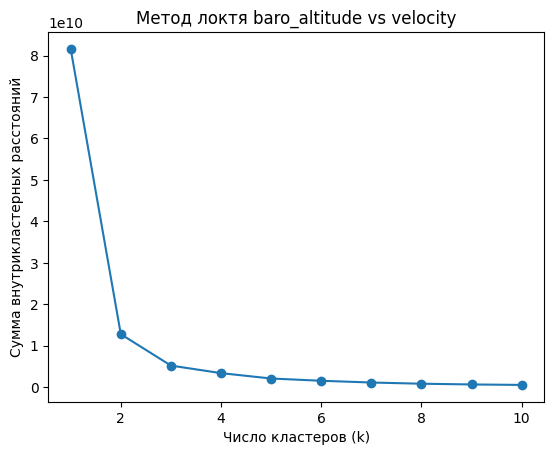

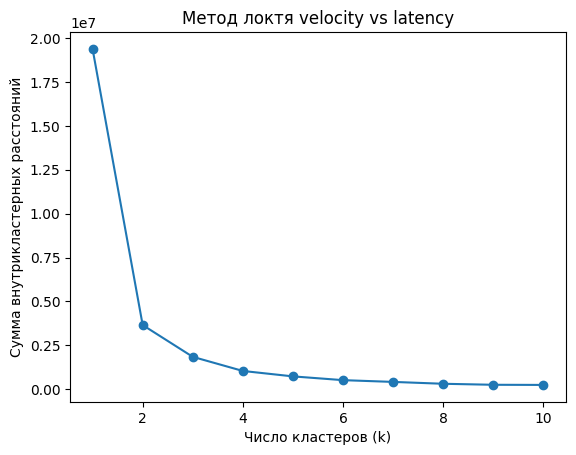

In [59]:

def elbow_method(colums1, colums2):
    inertia = []
    for k in range(1, 11):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(df[[colums1, colums2]])
        inertia.append(kmeans.inertia_)
    # Строим график
    plt.plot(range(1, 11), inertia, marker='o')
    plt.title(f"Метод локтя {colums1} vs {colums2}")
    plt.xlabel("Число кластеров (k)")
    plt.ylabel("Сумма внутрикластерных расстояний")
    plt.show()

elbow_method('longitude', 'latitude')
elbow_method('baro_altitude', 'velocity')
elbow_method('velocity', 'latency')

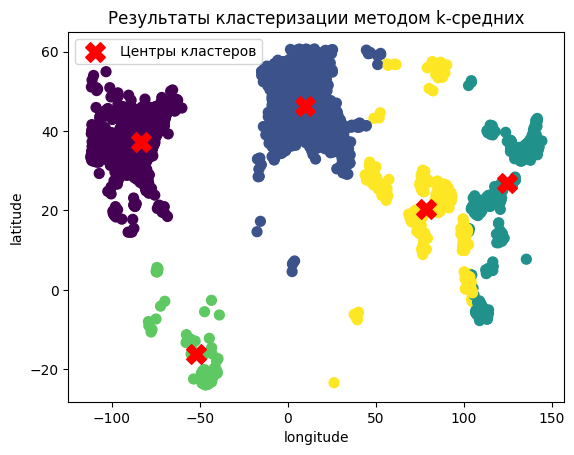

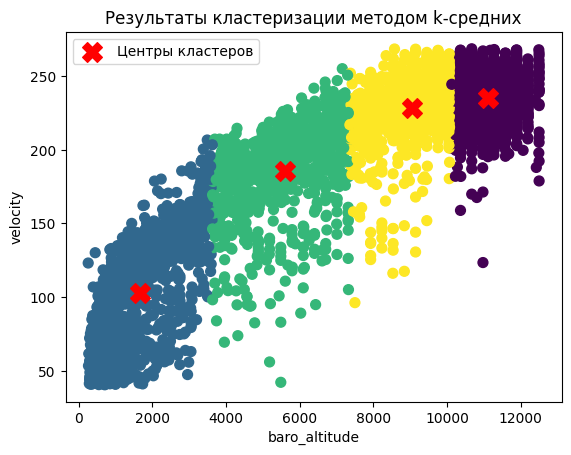

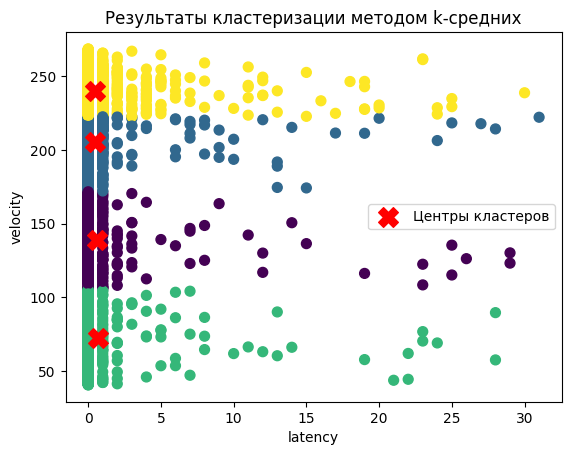

In [64]:
def clusters(colums1, colums2, value_k):
# k-средних
    kmeans = KMeans(n_clusters=value_k)
    kmeans.fit(df[[colums1, colums2]])

    labels = kmeans.labels_ # Массив меток кластеров
    centroids = kmeans.cluster_centers_ # Центры кластеров

    plt.scatter(df[colums1], df[colums2], c=labels, s=50, cmap='viridis')
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Центры кластеров')

    plt.title("Результаты кластеризации методом k-средних")
    plt.xlabel(colums1)
    plt.ylabel(colums2)
    plt.legend()
    plt.show()


clusters('longitude', 'latitude', 5)
clusters('baro_altitude', 'velocity', 4)
clusters('latency', 'velocity', 4)